In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, precision_score, recall_score, f1_score
from catboost import CatBoostClassifier
import optuna
from typing import Tuple
import joblib
from datetime import datetime
import os
import shap
from matplotlib import pyplot as plt

/Users/senpaka/programming/ml_learning/.artif_venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_csv('../data/customer.csv')

# feature engeenering


In [4]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'])

numerical_features = ['MonthlyCharges', 'TotalCharges', 'tenure']


In [5]:
df['Has_internet'] = (df['InternetService'] != 'No').astype(int)
df['PhoneService'] = (df['PhoneService'] == 'Yes').astype(int)

internet_services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['NumServices'] = 0

for service in internet_services:
    df[service] = (df[service] == 'Yes').astype(int)
    df['NumServices'] += df[service]

df['has_services'] = np.where(df['NumServices'] != 0, 1, 0).astype(int)
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Has_internet,NumServices,has_services
0,7590-VHVEG,Female,0,Yes,No,1,0,No phone service,DSL,0,...,0,Month-to-month,Yes,Electronic check,29.85,29.85,No,1,1,1
1,5575-GNVDE,Male,0,No,No,34,1,No,DSL,1,...,0,One year,No,Mailed check,56.95,1889.50,No,1,2,1
2,3668-QPYBK,Male,0,No,No,2,1,No,DSL,1,...,0,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,2,1
3,7795-CFOCW,Male,0,No,No,45,0,No phone service,DSL,1,...,0,One year,No,Bank transfer (automatic),42.30,1840.75,No,1,3,1
4,9237-HQITU,Female,0,No,No,2,1,No,Fiber optic,0,...,0,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,1,Yes,DSL,1,...,1,One year,Yes,Mailed check,84.80,1990.50,No,1,5,1
7039,2234-XADUH,Female,0,Yes,Yes,72,1,Yes,Fiber optic,0,...,1,One year,Yes,Credit card (automatic),103.20,7362.90,No,1,4,1
7040,4801-JZAZL,Female,0,Yes,Yes,11,0,No phone service,DSL,1,...,0,Month-to-month,Yes,Electronic check,29.60,346.45,No,1,1,1
7041,8361-LTMKD,Male,1,Yes,No,4,1,Yes,Fiber optic,0,...,0,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,1,0,0


# Modeling

In [6]:
bool_features = ['Partner', 'Dependents', 'PaperlessBilling', 'gender', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

cat_features = ["Contract", "PaymentMethod", "InternetService", "MultipleLines", 'Partner', 'Dependents', 'PaperlessBilling', 'gender', 'has_services']

to_drop = ['customerID', 'TotalCharges']

df_train = df.copy(deep=True)

df_train.drop(to_drop, axis=1, inplace=True)
df_train['Churn'] = np.where(df_train['Churn'] == 'Yes', 1, 0).astype(int)

numerical_features = ['MonthlyCharges', 'tenure', 'NumServices']

In [7]:


def create_features(df: pd.DataFrame):
    X = df.drop('Churn', axis=1)
    y = df['Churn']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    trf = ColumnTransformer(transformers=[
        ("StandardScaler", StandardScaler(), numerical_features),
        ("OHE", OneHotEncoder(drop='first'), cat_features),
        ]
    )

    X_train_trf = trf.fit_transform(X_train)
    X_test_trf = trf.transform(X_test)

    return X_train_trf, X_test_trf, y_train, y_test, trf

def calc_metrics(y_test: pd.Series, y_pred: pd.Series, y_proba: pd.Series) -> Tuple[float, float, float, float]:
    roc_auc = roc_auc_score(y_test, y_proba)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f'roc-auc: {roc_auc}')
    print(f'precision: {precision}')
    print(f'recall: {recall}')
    print(f'f1: {f1}')

    return roc_auc, precision, recall, f1


In [8]:
X_train, X_test, y_train, y_test, trf = create_features(df_train)

def optim(trial):

    model = LogisticRegression(
        random_state=42,
        class_weight='balanced',
        C=trial.suggest_float('C', 0.01, 10.0, log=True),
        l1_ratio=0,
        solver='lbfgs',
        max_iter=1000
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_score = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')

    return cv_score.mean()

study = optuna.create_study(direction='maximize', study_name='LogisticRegression study', storage='sqlite:///study.db', load_if_exists=True)
study.optimize(func=optim, n_trials=100, n_jobs=-1, show_progress_bar=True)

print(f'Best params: {study.best_params}')
print(f'Best roc-auc: {study.best_value:.4f}')

[I 2026-05-17 23:15:10,943] Using an existing study with name 'LogisticRegression study' instead of creating a new one.
Best trial: 314. Best value: 0.843466:   8%|▊         | 8/100 [00:00<00:04, 21.59it/s]

[I 2026-05-17 23:15:11,306] Trial 500 finished with value: 0.8434591319211406 and parameters: {'C': 1.3381992164463572}. Best is trial 314 with value: 0.843466407417521.
[I 2026-05-17 23:15:11,326] Trial 501 finished with value: 0.8434421622751799 and parameters: {'C': 1.3513408202184247}. Best is trial 314 with value: 0.843466407417521.
[I 2026-05-17 23:15:11,348] Trial 502 finished with value: 0.843437308362517 and parameters: {'C': 1.3639669186285386}. Best is trial 314 with value: 0.843466407417521.
[I 2026-05-17 23:15:11,366] Trial 504 finished with value: 0.8434462034578496 and parameters: {'C': 1.3432775934247085}. Best is trial 314 with value: 0.843466407417521.
[I 2026-05-17 23:15:11,368] Trial 503 finished with value: 0.8434542711706052 and parameters: {'C': 1.313839080729499}. Best is trial 314 with value: 0.843466407417521.
[I 2026-05-17 23:15:11,372] Trial 505 finished with value: 0.8434437808972934 and parameters: {'C': 1.361273765920724}. Best is trial 314 with value: 0.

Best trial: 314. Best value: 0.843466:  14%|█▍        | 14/100 [00:00<00:04, 18.93it/s]

[I 2026-05-17 23:15:11,549] Trial 508 finished with value: 0.8434389152625632 and parameters: {'C': 1.2881872377339911}. Best is trial 314 with value: 0.843466407417521.
[I 2026-05-17 23:15:11,596] Trial 509 finished with value: 0.8434405299773211 and parameters: {'C': 1.2891861084906961}. Best is trial 314 with value: 0.843466407417521.
[I 2026-05-17 23:15:11,663] Trial 510 finished with value: 0.8434130632201757 and parameters: {'C': 1.73002428512493}. Best is trial 314 with value: 0.843466407417521.
[I 2026-05-17 23:15:11,697] Trial 511 finished with value: 0.8433896239699552 and parameters: {'C': 1.7576994407798496}. Best is trial 314 with value: 0.843466407417521.
[I 2026-05-17 23:15:11,697] Trial 512 finished with value: 0.8433775219124021 and parameters: {'C': 1.8992920855687425}. Best is trial 314 with value: 0.843466407417521.
[I 2026-05-17 23:15:11,712] Trial 514 finished with value: 0.8433888317535796 and parameters: {'C': 1.8154724292308546}. Best is trial 314 with value: 0

Best trial: 314. Best value: 0.843466:  19%|█▉        | 19/100 [00:01<00:03, 22.88it/s]

...

Best trial: 314. Best value: 0.843466:  89%|████████▉ | 89/100 [00:03<00:00, 22.47it/s]

[I 2026-05-17 23:15:14,641] Trial 584 finished with value: 0.8434526769694649 and parameters: {'C': 1.5019411132862677}. Best is trial 314 with value: 0.843466407417521.
[I 2026-05-17 23:15:14,666] Trial 585 finished with value: 0.8434348799409271 and parameters: {'C': 1.4843288556702041}. Best is trial 314 with value: 0.843466407417521.
[I 2026-05-17 23:15:14,747] Trial 586 finished with value: 0.8434348750567324 and parameters: {'C': 1.5732781882909044}. Best is trial 314 with value: 0.843466407417521.
[I 2026-05-17 23:15:14,774] Trial 587 finished with value: 0.8434276073750635 and parameters: {'C': 1.4533022618214333}. Best is trial 314 with value: 0.843466407417521.
[I 2026-05-17 23:15:14,825] Trial 588 finished with value: 0.8434445819052193 and parameters: {'C': 1.554313632340927}. Best is trial 314 with value: 0.843466407417521.


[I 2026-05-17 23:15:14,875] Trial 589 finished with value: 0.8434259955908227 and parameters: {'C': 1.61584651015879}. Best is trial 314 with value: 0.843466407417521.
[I 2026-05-17 23:15:14,913] Trial 590 finished with value: 0.8434065838475266 and parameters: {'C': 1.646826453856797}. Best is trial 314 with value: 0.843466407417521.
[I 2026-05-17 23:15:14,941] Trial 591 finished with value: 0.8434227632307902 and parameters: {'C': 1.6167493905341328}. Best is trial 314 with value: 0.843466407417521.
[I 2026-05-17 23:15:14,981] Trial 592 finished with value: 0.8434049837853529 and parameters: {'C': 1.7378033549920702}. Best is trial 314 with value: 0.843466407417521.
[I 2026-05-17 23:15:15,017] Trial 593 finished with value: 0.8434065848243655 and parameters: {'C': 1.6727722509464762}. Best is trial 314 with value: 0.843466407417521.


Best trial: 314. Best value: 0.843466: 100%|██████████| 100/100 [00:04<00:00, 23.81it/s]

[I 2026-05-17 23:15:15,075] Trial 594 finished with value: 0.8433936885967593 and parameters: {'C': 1.964528946233012}. Best is trial 314 with value: 0.843466407417521.
[I 2026-05-17 23:15:15,092] Trial 595 finished with value: 0.8433734856139271 and parameters: {'C': 1.904266712374206}. Best is trial 314 with value: 0.843466407417521.
[I 2026-05-17 23:15:15,113] Trial 596 finished with value: 0.8434106465206531 and parameters: {'C': 1.8602031377962993}. Best is trial 314 with value: 0.843466407417521.
[I 2026-05-17 23:15:15,136] Trial 597 finished with value: 0.8433783629707243 and parameters: {'C': 4.013484643343385}. Best is trial 314 with value: 0.843466407417521.
[I 2026-05-17 23:15:15,149] Trial 598 finished with value: 0.8433880307456537 and parameters: {'C': 1.9528351489163465}. Best is trial 314 with value: 0.843466407417521.
[I 2026-05-17 23:15:15,151] Trial 599 finished with value: 0.8433815660255888 and parameters: {'C': 1.9856459820171257}. Best is trial 314 with value: 0.

In [9]:
study = optuna.load_study(study_name='LogisticRegression study', storage='sqlite:///study.db')

model_lr = LogisticRegression(
        random_state=42,
        class_weight='balanced',
        C=study.best_params['C'],
        l1_ratio=0,
        solver='lbfgs',
        max_iter=1000)

model_lr.fit(X_train, y_train)

y_proba = model_lr.predict_proba(X_test)[:, 1]
y_pred = model_lr.predict(X_test)

print(y_pred)

roc_auc, precision, recall, f1 = calc_metrics(y_test, y_pred, y_proba)

lr_cv = cross_val_score(model_lr, X_train, y_train, cv=5, scoring='roc_auc')

print(f'lr_cv: {lr_cv}')
print(f'mean cv: {lr_cv.mean():.4f}+-{lr_cv.std():.4f}')

print('-' * 70)

importance_df = pd.DataFrame({
    'features': trf.get_feature_names_out(),
    'importance_cb': model_lr.coef_[0]}
    )

print(pd.DataFrame(importance_df).sort_values(by='importance_cb', ascending=False))

threshold = 0.6

y_pred_thr = (y_proba > threshold).astype(int)

roc_auc, precision, recall, f1 = calc_metrics(y_test, y_pred_thr, y_proba)

print('New threshold:', threshold)
print(classification_report(y_test, y_pred_thr))

[0 1 0 ... 0 0 0]
roc-auc: 0.837608824821101
precision: 0.4965156794425087
recall: 0.7620320855614974
f1: 0.6012658227848101
lr_cv: [0.86128884 0.8501648  0.8480644  0.83223062 0.8205081 ]
mean cv: 0.8425+-0.0144
----------------------------------------------------------------------
                                      features  importance_cb
0               StandardScaler__MonthlyCharges       1.888092
10         OHE__MultipleLines_No phone service       1.733086
9                      OHE__InternetService_No       0.702452
6          OHE__PaymentMethod_Electronic check       0.447802
14                   OHE__PaperlessBilling_Yes       0.374861
7              OHE__PaymentMethod_Mailed check       0.067411
15                            OHE__gender_Male       0.048528
12                            OHE__Partner_Yes       0.035446
11                      OHE__MultipleLines_Yes      -0.005126
5   OHE__PaymentMethod_Credit card (automatic)      -0.008042
16                         OHE__ha

In [10]:
models = {}
features = list(pd.DataFrame(importance_df).sort_values(by='importance_cb', ascending=False)['features'].apply(lambda x: x.split('__')[1]))

models['LogReg'] = {
    'model': model_lr,
    'transform': trf,
    'params': model_lr.get_params(),
    'threshold': threshold,
    'cv': {
        'roc_auc': lr_cv.mean(),
        'std': lr_cv.std(),
    },
    'metrics': {
        'roc_auc': roc_auc,
        'precision': precision,
        'recall': recall,
        'f1': f1
    },
    'best_pos_features': features[:5],
    'best_neg_features': features[-1:-5:-1],
    'features': features
}

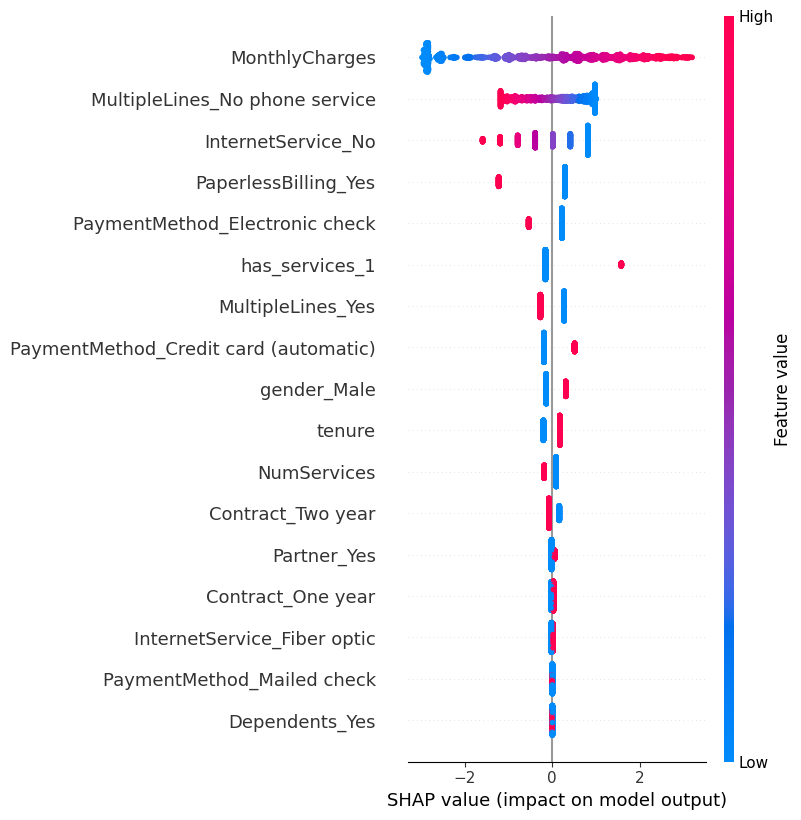

In [11]:
features = (pd.DataFrame(importance_df).sort_values(by='importance_cb', ascending=False))

expl = shap.LinearExplainer(model_lr, masker=X_train)
shap_val = expl.shap_values(X_test)

shap.summary_plot(shap_val, X_test, feature_names=list(features['features'].apply(lambda x: x.split('__')[1])))

In [12]:
X = df_train.drop('Churn', axis=1)
y = df_train['Churn']

print(X.columns, X.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

def optim(trial):

    model = CatBoostClassifier(
        iterations=1000,
        learning_rate=trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        depth=trial.suggest_int('depth', 3, 8),
        l2_leaf_reg=trial.suggest_float('l2_leaf_reg', 1, 10),
        random_strength=trial.suggest_float('random_strength', 1, 10),
        bagging_temperature=trial.suggest_float('bagging_temperature', 0, 1),
        auto_class_weights='Balanced',
        random_seed=42,
        verbose=False,
        thread_count=-1
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_score = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', params={'cat_features': cat_features})

    return cv_score.mean()

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'Has_internet', 'NumServices', 'has_services'],
      dtype='str') (7043, 21)


In [12]:
study = optuna.create_study(direction='maximize', storage='sqlite:///study.db', load_if_exists=True, study_name='CatBoostClassifier study')
study.optimize(optim, n_trials=100, n_jobs=-1, show_progress_bar=True)

print(f'Best params: {study.best_params}')
print(f'Best roc-auc: {study.best_value}')

[I 2026-05-04 19:31:02,124] Using an existing study with name 'CatBoostClassifier study' instead of creating a new one.
  0%|          | 0/100 [00:10<?, ?it/s]


KeyboardInterrupt: 

In [13]:
study = optuna.load_study(study_name='CatBoostClassifier study', storage='sqlite:///study.db')

cb = CatBoostClassifier(
    iterations=1000,
    random_seed=42,
    verbose=100,
    auto_class_weights='Balanced',
    **study.best_params
)

cb.fit(X_train, y_train, cat_features=cat_features)

y_proba = cb.predict_proba(X_test)[:, 1]
y_pred = cb.predict(X_test)

roc_auc, precision, recall, f1 = calc_metrics(y_test, y_pred, y_proba)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

cv_cb = cross_val_score(
    cb,
    X_train,
    y_train,
    cv=cv,
    scoring='roc_auc',
    params={'cat_features': cat_features},
)

print(f'Scores CatBoost: {cv_cb}')
print(f'Meam CatBoost: {cv_cb.mean():.4f}+-{cv_cb.std():.4f}')


0:	learn: 0.6876694	total: 8.92ms	remaining: 8.91s
100:	learn: 0.5186858	total: 624ms	remaining: 5.55s
200:	learn: 0.5004199	total: 1.44s	remaining: 5.74s
300:	learn: 0.4933935	total: 2.19s	remaining: 5.09s


{MultipleLines} pr2 tb0 type0, border=4 score 2.002027702
{PaymentMethod} pr2 tb0 type0, border=8 score 0.9081572808

{MultipleLines, PaymentMethod} pr1 tb0 type0, border=10 score 1.334051071
{Contract, StreamingMovies b0} pr0 tb0 type1, border=3 score 2.790223587
{InternetService, PaymentMethod} pr0 tb0 type0, border=10 score 1.518400462
{MultipleLines} pr1 tb0 type0, border=4 score 2.096539761

{InternetService} pr0 tb0 type0, border=0 score 0.8647030706

{Contract} pr2 tb0 type0, border=1 score 1.517223443
tenure, bin=70 score 1.304323936
MonthlyCharges, bin=240 score 2.193218242
tenure, bin=1 score 0.7650307277


tenure, bin=5 score 2.088413364

{MultipleLines} pr2 tb0 type0, border=4 score 2.121465751
{Contract} pr1 tb0 type0, border=5 score 1.40011303
{MultipleLines} pr0 tb0

[I 2026-05-04 19:31:48,492] Trial 142 finished with value: 0.8501150110624079 and parameters: {'learning_rate': 0.01162813340052613, 'depth': 3, 'l2_leaf_reg': 2.9957783473962256, 'random_strength': 2.07902020561267, 'bagging_temperature': 0.46467288242248334}. Best is trial 94 with value: 0.8510081119440226.
[I 2026-05-04 19:31:48,578] Trial 140 finished with value: 0.8508465271549209 and parameters: {'learning_rate': 0.018841455663366112, 'depth': 3, 'l2_leaf_reg': 2.999571199659463, 'random_strength': 4.743636140772963, 'bagging_temperature': 0.46650465187681966}. Best is trial 94 with value: 0.8510081119440226.
[I 2026-05-04 19:31:48,589] Trial 145 finished with value: 0.8507589442645205 and parameters: {'learning_rate': 0.01790543376649087, 'depth': 3, 'l2_leaf_reg': 1.1883186179870824, 'random_strength': 4.884828922797108, 'bagging_temperature': 0.3947695014714281}. Best is trial 94 with value: 0.8510081119440226.
[I 2026-05-04 19:31:49,282] Trial 141 finished with value: 0.85045

500:	learn: 0.4782184	total: 4.1s	remaining: 4.08s


[I 2026-05-04 19:31:49,605] Trial 146 finished with value: 0.8504482298711444 and parameters: {'learning_rate': 0.011524927182683503, 'depth': 3, 'l2_leaf_reg': 3.0085029242118697, 'random_strength': 1.1794214667132357, 'bagging_temperature': 0.5703754957540034}. Best is trial 94 with value: 0.8510081119440226.


600:	learn: 0.4670723	total: 4.48s	remaining: 2.98s


[I 2026-05-04 19:31:49,893] Trial 143 finished with value: 0.8505631789042802 and parameters: {'learning_rate': 0.018651457580019043, 'depth': 3, 'l2_leaf_reg': 3.1324278922590434, 'random_strength': 1.0970732547101283, 'bagging_temperature': 0.40909620681685466}. Best is trial 94 with value: 0.8510081119440226.


700:	learn: 0.4591968	total: 4.79s	remaining: 2.04s
800:	learn: 0.4536422	total: 5.09s	remaining: 1.26s


[I 2026-05-04 19:31:50,517] Trial 144 finished with value: 0.8465080948395729 and parameters: {'learning_rate': 0.048359366547604754, 'depth': 3, 'l2_leaf_reg': 3.1109475646064224, 'random_strength': 3.2140026586245685, 'bagging_temperature': 0.5707538036897888}. Best is trial 94 with value: 0.8510081119440226.


900:	learn: 0.4494968	total: 5.34s	remaining: 587ms
999:	learn: 0.4455995	total: 5.56s	remaining: 0us
0:	learn: 0.6867493	total: 1.47ms	remaining: 1.47s
100:	learn: 0.5320350	total: 137ms	remaining: 1.22s
200:	learn: 0.5096893	total: 316ms	remaining: 1.26s
300:	learn: 0.5015185	total: 602ms	remaining: 1.4s
400:	learn: 0.4957220	total: 760ms	remaining: 1.14s
500:	learn: 0.4882081	total: 909ms	remaining: 905ms
600:	learn: 0.4774299	total: 1.16s	remaining: 768ms
700:	learn: 0.4693974	total: 1.54s	remaining: 658ms
800:	learn: 0.4640791	total: 1.75s	remaining: 435ms
900:	learn: 0.4595414	total: 1.96s	remaining: 216ms
999:	learn: 0.4554910	total: 2.12s	remaining: 0us
Scores CatBoost: [0.84343679 0.84336331 0.86400648]
Meam CatBoost: 0.8503+-0.0097


In [15]:
threshold = 0.59

y_pred_thr = (y_proba > threshold).astype(int)

roc_auc, precision, recall, f1 = calc_metrics(y_test, y_pred_thr, y_proba)

roc-auc: 0.847257743677181
precision: 0.5614754098360656
recall: 0.732620320855615
f1: 0.6357308584686775


In [16]:
features = list(pd.DataFrame({
    'features': cb.feature_names_,
    'importance': cb.feature_importances_
    }
).sort_values(by='importance', ascending=False)['features'])

models['CatBoost'] = {
    'model': cb,
    'params': cb.get_params(),
    'threshold': threshold,
    'cv': {
        'roc_auc': cv_cb.mean(),
        'std': cv_cb.std(),
    },
    'metrics': {
        'roc_auc': roc_auc,
        'precision': precision,
        'recall': recall,
        'f1': f1
    },
    'best_features': features[:10],
    'features': X_train.columns.tolist()
}

In [17]:
results = []
for model_name, data in models.items():
    results.append({
        'Модель': model_name,
        'ROC-AUC (CV)': f"{data['cv']['roc_auc']:.4f} ± {data['cv']['std']:.4f}",
        'Precision': f"{data['metrics']['precision']:.3f}",
        'Recall': f"{data['metrics']['recall']:.3f}",
        'F1': f"{data['metrics']['f1']:.3f}",
        'Порог': data['threshold']
    })

df_results = pd.DataFrame(results)
print(df_results.to_markdown(index=False))

| Модель   | ROC-AUC (CV)    |   Precision |   Recall |    F1 |   Порог |
|:---------|:----------------|------------:|---------:|------:|--------:|
| LogReg   | 0.8425 ± 0.0144 |       0.549 |    0.695 | 0.613 |    0.6  |
| CatBoost | 0.8503 ± 0.0097 |       0.561 |    0.733 | 0.636 |    0.59 |


/var/folders/9t/g_89yb8s6mg5h36d2l2wy47h0000gn/T/ipykernel_93129/417727172.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in X_test_display.select_dtypes(include=['object']).columns:


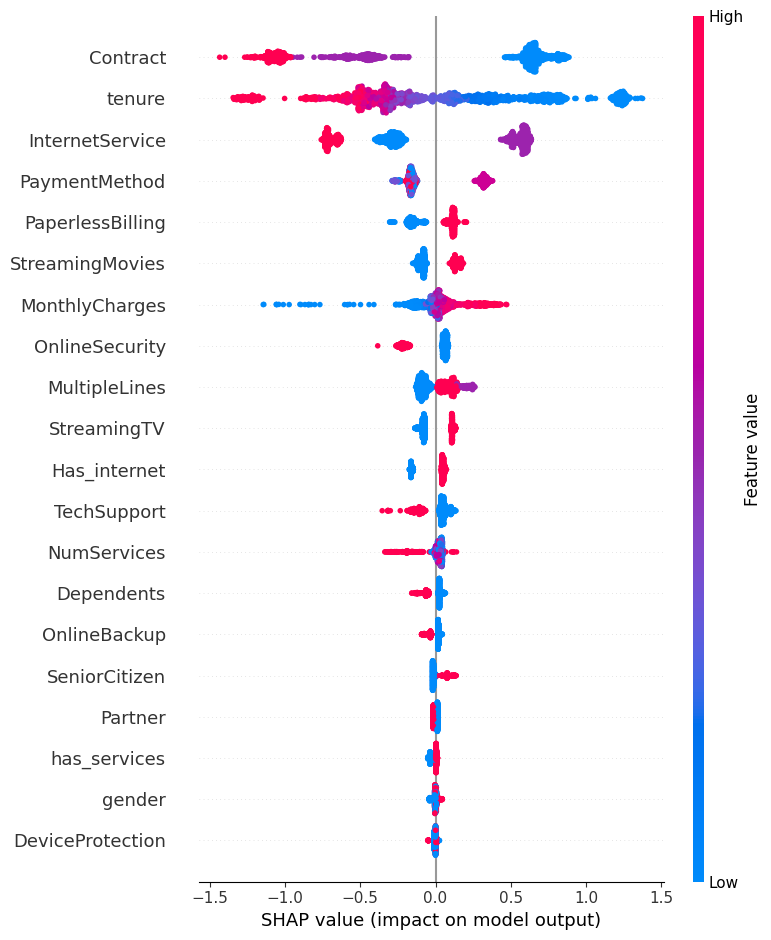

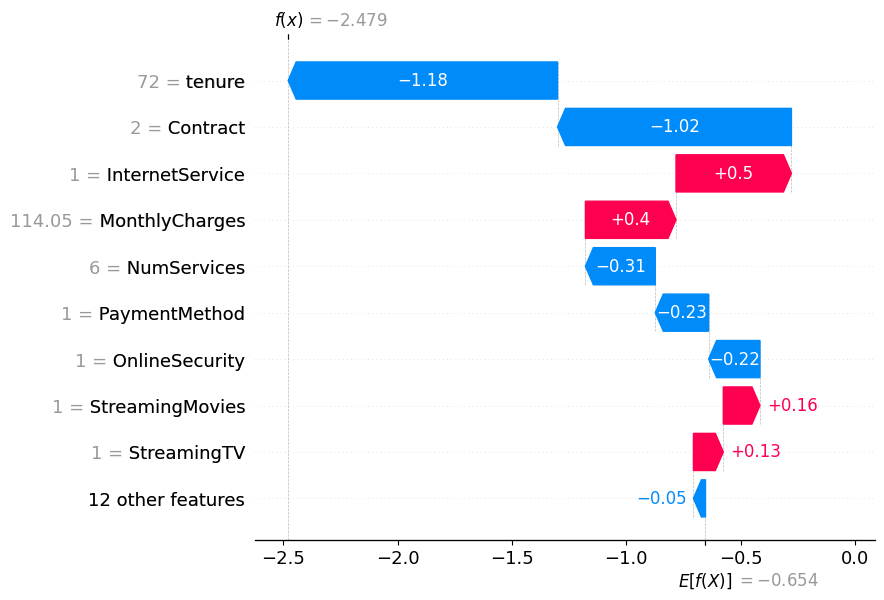

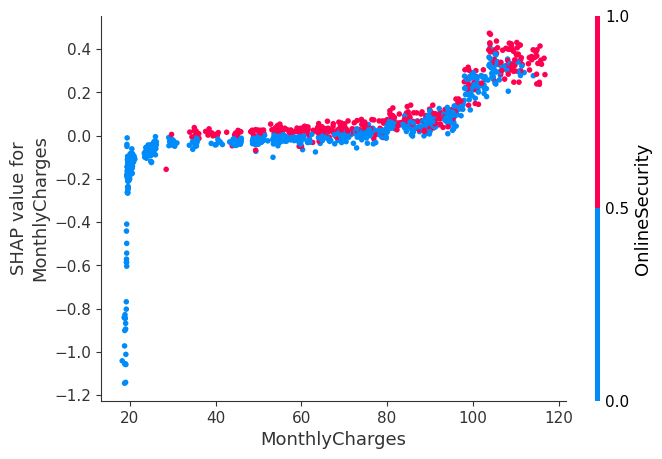

In [44]:


features = (pd.DataFrame({
    'features': cb.feature_names_,
    'importance': cb.feature_importances_
    }
).sort_values(by='importance', ascending=False))

X_test_display = X_test.copy()

for col in X_test_display.select_dtypes(include=['object']).columns:
    X_test_display[col] = X_test_display[col].astype('category').cat.codes

expl = shap.TreeExplainer(cb)
shap_val = expl.shap_values(X_test)

shap.summary_plot(shap_val, X_test_display, feature_names=cb.feature_names_)
plt.show()

base = expl.expected_value
first = shap_val[0]

shap_expl = shap.Explanation(
    values=first,
    base_values=base,
    data=X_test_display.iloc[0].values,
    feature_names=cb.feature_names_
)

shap.plots.waterfall(shap_expl, max_display=10, show=True)
plt.show()

top_feature = features.iloc[3]['features']

shap.dependence_plot(
    top_feature,
    shap_val,
    X_test_display,
    feature_names=cb.feature_names_,
    show=True
)
plt.show()



# Save Model

In [224]:
date = datetime.today().strftime('%d-%m-%Y')

for model_name, data in models.items():
    if not os.path.exists('../models'):
        os.mkdir('../models')
    joblib.dump(data, f'../models/{model_name}-{date}.pkl')